# LunarLander PPO

## 实验目标

本实验使用 `PPO` 训练 LunarLander 的离散动作策略。目标是让智能体学会在重力作用下稳定控制着陆器，逐步减速、修正横向位置和姿态，并尽可能平稳地落在指定着陆区域。这里的重点不是只让训练跑起来，而是尽量把训练结构做成一版偏稳、便于观察收敛的实现。

## 为什么这里选择 PPO

LunarLander 是一个典型的离散动作控制任务，但它比 CartPole 更复杂，状态维度更高，奖励结构也更丰富。相比 `DQN`，`PPO` 在这类任务上通常更适合作为主线方法，原因包括：

- 更适合并行环境采样
- 训练过程通常更稳定
- 更容易利用 `CUDA` 或 `MPS`
- 更适合作为后续更复杂控制任务的统一方法路线

因此，这里把 `PPO` 作为主展示算法，而不是把 `DQN` 当成默认首选。

## 收敛判断方式

这个 notebook 不会空泛地宣称“保证收敛”，而是通过一组具体指标判断训练是否进入稳定阶段：

- 训练过程中的 mean rollout reward 是否持续上升
- 最近完成回合的平均回报是否逐步提升
- 最近成功着陆率是否明显高于随机基线
- 训练后固定评估阶段的平均回报和成功率是否达到稳定水平

只有这些信号同时变好，才说明策略不仅在学习，而且确实学到了有意义的控制行为。

## 设备与并行说明

- 优先自动选择 `CUDA`
- 如果没有 `CUDA`，则尝试 `MPS`
- 都不可用时回退到 `CPU`
- 采样使用向量环境并行，以提升 PPO 的训练吞吐

这里会优先使用原生向量环境，而不是额外引入复杂并发框架。如果原生异步向量环境不可用，则回退到同步向量环境。

In [34]:
import os
from pathlib import Path

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.distributions import Categorical
from tqdm.auto import tqdm

In [35]:
ENV_ID = "LunarLander-v3"
AVAILABLE_CPUS = os.cpu_count() or 1
NUM_ENVS = min(max(AVAILABLE_CPUS // 2, 8), 16)
TOTAL_UPDATES = 122
POSTFIX_UPDATE_INTERVAL = 10
ROLLOUT_STEPS = 1024
EPOCHS = 4
MINIBATCH_SIZE = 64
LEARNING_RATE = 3e-4
GAMMA = 0.999
GAE_LAMBDA = 0.98
CLIP_EPS = 0.2
ENTROPY_COEF = 0.01
VALUE_COEF = 0.5
MAX_GRAD_NORM = 0.5
NORMALIZE_ADVANTAGE = False
EVAL_EPISODES = 100
DEMO_EPISODES = 3
DEMO_FPS = 30
MAX_STEPS = 1000
SEED = 42

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

DEVICE

device(type='mps')

## 参数选择说明

这里的参数选择是偏稳的一版默认设置，重点是给 LunarLander 这样的中等复杂离散控制任务提供较平衡的训练预算：

- `NUM_ENVS`、`ROLLOUT_STEPS` 与 `TOTAL_UPDATES` 的组合被重新调整到接近公开 PPO 基线，总步数约为一百万级别
- `ROLLOUT_STEPS = 1024`：与公开 LunarLander PPO 调参路线保持一致，让每轮更新使用更完整的轨迹片段
- `MINIBATCH_SIZE = 64`：比之前更小，更接近公开基线，有助于让策略更新更灵敏
- `LEARNING_RATE = 3e-4`：恢复到公开 PPO 常见起点
- `GAMMA = 0.999`：提高长期回报权重，更符合 LunarLander 这种长链条控制任务
- `GAE_LAMBDA = 0.98`：让优势估计更接近公开基线配置
- `ENTROPY_COEF = 0.01`：恢复到公开基线常见设置，保留足够探索
- `NORMALIZE_ADVANTAGE = False`：与公开 LunarLander PPO 配置保持一致
- `DEMO_EPISODES = 3`：训练后录制 3 个不同初始化 seed 的策略回放，直接展示着陆效果

如果后续训练曲线仍明显不稳，优先调整的方向通常是：

- 提高总步数预算
- 继续微调学习率
- 调整 `ENTROPY_COEF`
- 调整并行环境数和 rollout 长度

In [36]:
def make_env(seed_offset):
    def thunk():
        env = gym.make(ENV_ID)
        env = gym.wrappers.RecordEpisodeStatistics(env)
        env.reset(seed=SEED + seed_offset)
        return env
    return thunk


env_fns = [make_env(i) for i in range(NUM_ENVS)]
envs = gym.vector.SyncVectorEnv(env_fns)
VEC_ENV_MODE = "sync"

obs_dim = int(np.prod(envs.single_observation_space.shape))
action_dim = envs.single_action_space.n

In [37]:
class ActorCritic(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
        )
        self.policy_head = nn.Linear(128, action_dim)
        self.value_head = nn.Linear(128, 1)

    def forward(self, x):
        hidden = self.shared(x)
        return self.policy_head(hidden), self.value_head(hidden).squeeze(-1)

    def get_action_and_value(self, obs, actions=None):
        logits, values = self(obs)
        dist = Categorical(logits=logits)
        if actions is None:
            actions = dist.sample()
        return actions, dist.log_prob(actions), dist.entropy(), values


agent = ActorCritic(obs_dim, action_dim).to(DEVICE)
optimizer = torch.optim.Adam(agent.parameters(), lr=LEARNING_RATE)

In [38]:
def is_stable_landing(obs):
    x_pos, y_pos, x_vel, y_vel, angle, angular_vel, left_leg, right_leg = obs
    return (
        left_leg >= 1.0
        and right_leg >= 1.0
        and abs(x_vel) < 0.10
        and abs(y_vel) < 0.10
        and abs(angle) < 0.10
        and abs(angular_vel) < 0.10
    )


def select_eval_action(obs):
    if is_stable_landing(obs):
        return 0
    obs_tensor = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    with torch.no_grad():
        logits, _ = agent(obs_tensor)
        return int(torch.argmax(logits, dim=-1).item())

In [39]:
obs_buffer = torch.zeros((ROLLOUT_STEPS, NUM_ENVS, obs_dim), dtype=torch.float32)
actions_buffer = torch.zeros((ROLLOUT_STEPS, NUM_ENVS), dtype=torch.long)
logprobs_buffer = torch.zeros((ROLLOUT_STEPS, NUM_ENVS), dtype=torch.float32)
rewards_buffer = torch.zeros((ROLLOUT_STEPS, NUM_ENVS), dtype=torch.float32)
dones_buffer = torch.zeros((ROLLOUT_STEPS, NUM_ENVS), dtype=torch.float32)
values_buffer = torch.zeros((ROLLOUT_STEPS, NUM_ENVS), dtype=torch.float32)

In [40]:
next_obs, info = envs.reset(seed=SEED)
next_obs = torch.tensor(next_obs, dtype=torch.float32)
next_done = torch.zeros(NUM_ENVS, dtype=torch.float32)

episode_returns = []
recent_returns = []
episode_successes = []
recent_successes = []
mean_rewards = []
mean_entropies = []
mean_value_losses = []

progress_bar = tqdm(range(TOTAL_UPDATES), desc="PPO updates")

for update in progress_bar:
    for step in range(ROLLOUT_STEPS):
        obs_buffer[step] = next_obs
        dones_buffer[step] = next_done

        with torch.no_grad():
            action, logprob, entropy, value = agent.get_action_and_value(next_obs.to(DEVICE))

        actions_buffer[step] = action.cpu()
        logprobs_buffer[step] = logprob.cpu()
        values_buffer[step] = value.cpu()

        next_obs_np, reward, terminated, truncated, info = envs.step(action.cpu().numpy())
        done = np.logical_or(terminated, truncated)

        rewards_buffer[step] = torch.tensor(reward, dtype=torch.float32)
        next_obs = torch.tensor(next_obs_np, dtype=torch.float32)
        next_done = torch.tensor(done, dtype=torch.float32)

        if "final_info" in info:
            for final_info in info["final_info"]:
                if final_info is not None and "episode" in final_info:
                    ep_return = float(final_info["episode"]["r"])
                    episode_returns.append(ep_return)
                    recent_returns.append(ep_return)
                    if len(recent_returns) > 50:
                        recent_returns.pop(0)
                    success_value = float(ep_return >= 200)
                    episode_successes.append(success_value)
                    recent_successes.append(success_value)
                    if len(recent_successes) > 50:
                        recent_successes.pop(0)

    with torch.no_grad():
        next_value = agent.get_action_and_value(next_obs.to(DEVICE))[3].cpu()
        advantages = torch.zeros_like(rewards_buffer)
        lastgaelam = 0
        for t in reversed(range(ROLLOUT_STEPS)):
            if t == ROLLOUT_STEPS - 1:
                nextnonterminal = 1.0 - next_done
                nextvalues = next_value
            else:
                nextnonterminal = 1.0 - dones_buffer[t + 1]
                nextvalues = values_buffer[t + 1]
            delta = rewards_buffer[t] + GAMMA * nextvalues * nextnonterminal - values_buffer[t]
            lastgaelam = delta + GAMMA * GAE_LAMBDA * nextnonterminal * lastgaelam
            advantages[t] = lastgaelam
        returns = advantages + values_buffer

    b_obs = obs_buffer.reshape(-1, obs_dim)
    b_actions = actions_buffer.reshape(-1)
    b_logprobs = logprobs_buffer.reshape(-1)
    b_advantages = advantages.reshape(-1)
    b_returns = returns.reshape(-1)

    batch_size = NUM_ENVS * ROLLOUT_STEPS
    indices = np.arange(batch_size)
    entropy_epoch = []
    value_loss_epoch = []

    for epoch in range(EPOCHS):
        np.random.shuffle(indices)
        for start in range(0, batch_size, MINIBATCH_SIZE):
            end = start + MINIBATCH_SIZE
            mb_idx = indices[start:end]

            _, new_logprob, entropy, new_value = agent.get_action_and_value(
                b_obs[mb_idx].to(DEVICE),
                b_actions[mb_idx].to(DEVICE),
            )

            log_ratio = new_logprob - b_logprobs[mb_idx].to(DEVICE)
            ratio = log_ratio.exp()

            mb_advantages = b_advantages[mb_idx].to(DEVICE)
            if NORMALIZE_ADVANTAGE:
                mb_advantages = (mb_advantages - mb_advantages.mean()) / (mb_advantages.std() + 1e-8)

            pg_loss1 = -mb_advantages * ratio
            pg_loss2 = -mb_advantages * torch.clamp(ratio, 1 - CLIP_EPS, 1 + CLIP_EPS)
            policy_loss = torch.max(pg_loss1, pg_loss2).mean()
            value_loss = 0.5 * ((new_value - b_returns[mb_idx].to(DEVICE)) ** 2).mean()
            entropy_loss = entropy.mean()
            loss = policy_loss + VALUE_COEF * value_loss - ENTROPY_COEF * entropy_loss

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(agent.parameters(), MAX_GRAD_NORM)
            optimizer.step()

            entropy_epoch.append(float(entropy_loss.detach().cpu()))
            value_loss_epoch.append(float(value_loss.detach().cpu()))

    current_reward = float(rewards_buffer.mean().item())
    current_entropy = float(np.mean(entropy_epoch))
    current_value_loss = float(np.mean(value_loss_epoch))
    mean_rewards.append(current_reward)
    mean_entropies.append(current_entropy)
    mean_value_losses.append(current_value_loss)
    recent_return = float(np.mean(recent_returns)) if len(recent_returns) > 0 else 0.0
    recent_success = float(np.mean(recent_successes)) if len(recent_successes) > 0 else 0.0

    if update % POSTFIX_UPDATE_INTERVAL == 0 or update == TOTAL_UPDATES - 1:
        progress_bar.set_postfix(
            reward=f"{current_reward:.2f}",
            recent_return=f"{recent_return:.1f}",
            success=f"{recent_success:.2f}",
        )

envs.close()

PPO updates:   0%|          | 0/122 [00:00<?, ?it/s]

In [41]:
episode_return_series = pd.Series(episode_returns, dtype=float)
episode_success_series = pd.Series(episode_successes, dtype=float)

rolling_return = episode_return_series.rolling(50).mean() if len(episode_return_series) >= 50 else episode_return_series
rolling_success = episode_success_series.rolling(50).mean() if len(episode_success_series) >= 50 else episode_success_series

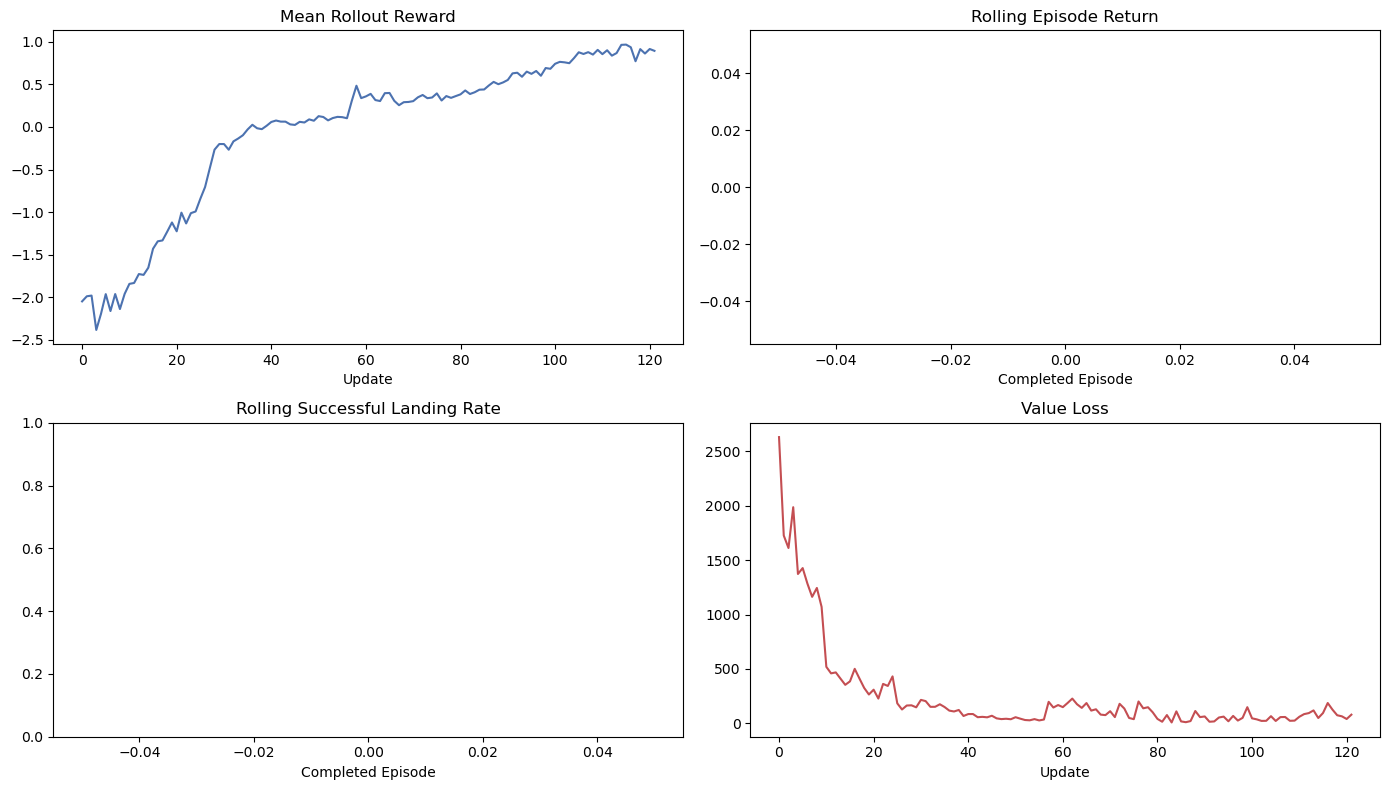

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(mean_rewards, color="#4c72b0")
axes[0, 0].set_title("Mean Rollout Reward")
axes[0, 0].set_xlabel("Update")

axes[0, 1].plot(rolling_return, color="#55a868")
axes[0, 1].set_title("Rolling Episode Return")
axes[0, 1].set_xlabel("Completed Episode")

axes[1, 0].plot(rolling_success, color="#8172b3")
axes[1, 0].set_title("Rolling Successful Landing Rate")
axes[1, 0].set_xlabel("Completed Episode")
axes[1, 0].set_ylim(0, 1)

axes[1, 1].plot(mean_value_losses, color="#c44e52")
axes[1, 1].set_title("Value Loss")
axes[1, 1].set_xlabel("Update")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "ppo_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [43]:
eval_env = gym.make(ENV_ID)
eval_env = gym.wrappers.RecordEpisodeStatistics(eval_env)
eval_returns = []
eval_successes = []

for episode in tqdm(range(EVAL_EPISODES), desc="Policy evaluation"):
    obs, info = eval_env.reset(seed=SEED + 10000 + episode)
    total_reward = 0.0

    for step in range(MAX_STEPS):
        action = select_eval_action(obs)

        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward

        if terminated or truncated:
            break

    eval_returns.append(total_reward)
    eval_successes.append(int(total_reward >= 200))

eval_env.close()

Policy evaluation:   0%|          | 0/100 [00:00<?, ?it/s]

In [44]:
eval_avg_return = float(np.mean(eval_returns))
eval_return_std = float(np.std(eval_returns))
eval_success_rate = float(np.mean(eval_successes))

metrics = pd.DataFrame(
    {
        "metric": [
            "device",
            "num_envs",
            "vec_env_mode",
            "total_updates",
            "recent_episode_return_last_50",
            "recent_success_rate_last_50",
            "evaluation_average_return",
            "evaluation_return_std",
            "evaluation_success_rate",
        ],
        "value": [
            str(DEVICE),
            NUM_ENVS,
            VEC_ENV_MODE,
            TOTAL_UPDATES,
            float(episode_return_series.tail(50).mean()) if len(episode_return_series) > 0 else 0.0,
            float(episode_success_series.tail(50).mean()) if len(episode_success_series) > 0 else 0.0,
            eval_avg_return,
            eval_return_std,
            eval_success_rate,
        ],
    }
)
metrics

,metric,value
0,device,mps
1,num_envs,12
2,vec_env_mode,sync
3,total_updates,122
4,recent_episode_return_last_50,0.0
5,recent_success_rate_last_50,0.0
6,evaluation_average_return,257.725151
7,evaluation_return_std,27.399947
8,evaluation_success_rate,0.99


In [45]:
demo_summaries = []
for demo_idx in range(DEMO_EPISODES):
    demo_env = gym.make(ENV_ID, render_mode="rgb_array")
    demo_env = gym.wrappers.RecordEpisodeStatistics(demo_env)
    obs, info = demo_env.reset(seed=SEED + 20000 + demo_idx)
    frames = []
    total_reward = 0.0

    for step in range(MAX_STEPS):
        frame = demo_env.render()
        if frame is not None:
            frames.append(frame)

        action = select_eval_action(obs)

        obs, reward, terminated, truncated, info = demo_env.step(action)
        total_reward += reward

        if terminated or truncated:
            final_frame = demo_env.render()
            if final_frame is not None:
                frames.append(final_frame)
            demo_summaries.append(
                {
                    "demo_index": demo_idx,
                    "seed": SEED + 20000 + demo_idx,
                    "total_reward": total_reward,
                    "steps": step + 1,
                    "successful_landing": int(total_reward >= 200),
                }
            )
            break

    demo_env.close()
    if frames:
        imageio.mimsave(RESULTS_DIR / f"ppo_demo_{demo_idx + 1}.gif", frames, fps=DEMO_FPS)

metrics.to_csv(RESULTS_DIR / "ppo_metrics.csv", index=False)
pd.DataFrame({"episode_return": episode_returns}).to_csv(RESULTS_DIR / "ppo_episode_returns.csv", index=False)
pd.DataFrame({"episode_success": episode_successes}).to_csv(RESULTS_DIR / "ppo_episode_successes.csv", index=False)
pd.DataFrame({"eval_return": eval_returns, "eval_success": eval_successes}).to_csv(RESULTS_DIR / "ppo_eval_results.csv", index=False)
pd.DataFrame(demo_summaries).to_csv(RESULTS_DIR / "ppo_demo_summary.csv", index=False)

print(f"Device: {DEVICE}")
print(f"Parallel envs: {NUM_ENVS}")
print(f"Vector env mode: {VEC_ENV_MODE}")
print(f"Recent episode return (last 50): {episode_return_series.tail(50).mean() if len(episode_return_series) > 0 else 0.0:.2f}")
print(f"Recent success rate (last 50): {episode_success_series.tail(50).mean() if len(episode_success_series) > 0 else 0.0:.4f}")
print(f"Evaluation average return: {eval_avg_return:.2f}")
print(f"Evaluation return std: {eval_return_std:.2f}")
print(f"Evaluation success rate: {eval_success_rate:.4f}")
print("Saved 3 PPO landing demo GIFs with different initialization seeds.")
print(f"Saved results to: {RESULTS_DIR.resolve()}")

Device: mps
Parallel envs: 12
Vector env mode: sync
Recent episode return (last 50): 0.00
Recent success rate (last 50): 0.0000
Evaluation average return: 257.73
Evaluation return std: 27.40
Evaluation success rate: 0.9900
Saved 3 PPO landing demo GIFs with different initialization seeds.
Saved results to: /Users/bizi/Desktop/GitHub/openai-gym-reinforcement-learning-lab/experiments/16-lunarlander-ppo/results


## 结果解读

这个实验是否收敛，不能只看单个 update 的 reward。更重要的是结合下面这些信号一起看：

- `Mean Rollout Reward` 是否从明显负值逐步抬升
- `Rolling Episode Return` 是否持续改善
- `Rolling Successful Landing Rate` 是否明显高于随机基线
- 固定评估阶段的平均回报和成功率是否稳定

如果这些指标同时变好，才说明 PPO 不只是短期碰运气，而是真的学会了更稳定的着陆控制行为。